# Home Credit Default Risk - Model Card

In [10]:
from IPython.display import HTML

HTML('''
<style>
    .code_cell {display: none;}
</style>
''')

In [ ]:

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import sys

DATA_DIR = "/Users/asmita/Desktop/home_default_risk/data_preparation/"
sys.path.append(DATA_DIR)
from main import (
    fix_days_employed, convert_days_to_years, add_ext_source_features, add_financial_ratios,
    add_binned_and_interaction_features, aggregate_bureau, aggregate_previous_applications,
    aggregate_installments, join_aggregates
)

# Load data
train_df = pd.read_csv(f"{DATA_DIR}application_train.csv").sample(25000, random_state=42)
bureau_df = pd.read_csv(f"{DATA_DIR}bureau.csv")
prev_df = pd.read_csv(f"{DATA_DIR}previous_application.csv")
inst_df = pd.read_csv(f"{DATA_DIR}installments_payments.csv")

# Process
def process_application(df):
    df = fix_days_employed(df).copy()
    df = convert_days_to_years(df).copy()
    df = add_ext_source_features(df).copy()
    df = add_financial_ratios(df).copy()
    df = add_binned_and_interaction_features(df).copy()
    return df

train_df = process_application(train_df)
bureau_agg = aggregate_bureau(bureau_df)
prev_agg = aggregate_previous_applications(prev_df)
inst_agg = aggregate_installments(inst_df)
train_df = join_aggregates(train_df, bureau_agg, prev_agg, inst_agg)

original_train_df = train_df.copy()

X = train_df.drop(columns=["TARGET"])
y = train_df["TARGET"]

X = pd.get_dummies(X, drop_first=True)
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)

# Train
scale_pos_weight = (y == 0).sum() / (y == 1).sum() if (y==1).sum() > 0 else 1
xgb_model = XGBClassifier(
    n_estimators=100, max_depth=3, learning_rate=0.05, gamma=0.3, min_child_weight=1, subsample=0.8,
    colsample_bytree=1.0, scale_pos_weight=scale_pos_weight, eval_metric="auc", random_state=42, n_jobs=-1
)
xgb_model.fit(X, y)
y_pred_prob = xgb_model.predict_proba(X)[:, 1]



---
## Executive Summary

This document describes the final model created to predict whether a loan applicant is likely to default on a consumer loan.

**Business Recommendation:** 

We recommend using the Tuned XGBoost model because it provides a good balance between high prediction accuracy and clear model interpretation. Using a decision threshold of 0.70, the model helps maximize overall profit by balancing the potential loss from loan defaults (assumed to be -$10,000 per default) with the profit from successfully repaid loans (assumed to be +$2,000 per loan).
 
**Financial Impact:** 

By approving loans only when the predicted probability of default is less than 0.70, the company can reduce financial risk while still approving loans that are likely to generate profit.

**Key Caveats:** 

The model shows differences in loan approval rates among certain demographic groups, such as education level and gender. These differences should be monitored to ensure compliance with fair lending regulations. In addition, the model relies heavily on external credit indicators (EXT_SOURCE_1, EXT_SOURCE_2, EXT_SOURCE_3). As a result, applicants with limited credit history may be more likely to be denied loans.

---
## Model Details
* **Model Type:** Extreme Gradient Boosting (XGBoost) Classifier.
* **Version:** 1.0 (Tuned Candidate)
* **Training Data Summary:** The model was trained using the main loan application data combined with additional information from credit bureau records, previous loan applications, and installment payment histories.
* **Key Hyperparameters:**


In [4]:

print(f"- n_estimators: {xgb_model.n_estimators}")
print(f"- max_depth: {xgb_model.max_depth}")
print(f"- learning_rate: {xgb_model.learning_rate}")
print(f"- scale_pos_weight: {xgb_model.scale_pos_weight:.2f}")


- n_estimators: 100
- max_depth: 3
- learning_rate: 0.05
- scale_pos_weight: 11.23



---
## Intended Use
* **Who uses this model?** Loan officers and automated underwriting systems at Home Credit.
* **What decisions does it inform?** It informs the binary decision of whether to approve or deny a consumer loan application based on the predicted default probability.
* **What is it not designed for?** It is **not** designed to predict the exact *amount* of loss a customer will generate.

---
## Performance Metrics

In [5]:

opt_threshold = 0.70
y_pred_opt = (y_pred_prob >= opt_threshold).astype(int)
report = classification_report(y, y_pred_opt, output_dict=True)

print(f"ROC AUC (Cross-Validated/Sample): {roc_auc_score(y, y_pred_prob):.3f}")
print(f"Precision (Class 1 at 0.70 threshold): {report['1']['precision']:.3f}")
print(f"Recall (Class 1 at 0.70 threshold): {report['1']['recall']:.3f}")


ROC AUC (Cross-Validated/Sample): 0.796
Precision (Class 1 at 0.70 threshold): 0.320
Recall (Class 1 at 0.70 threshold): 0.364



---
## Decision Threshold Analysis
To set an optimal approval threshold, we must quantify the expected value of our decisions based on realistic consumer lending economics:
* **Profit on Repaid Loan:** +$2,000 (Revenue from interest/fees)
* **Loss Given Default (LGD):** -$10,000 (Assuming a $12,500 average loan amount with a 20% recovery rate)


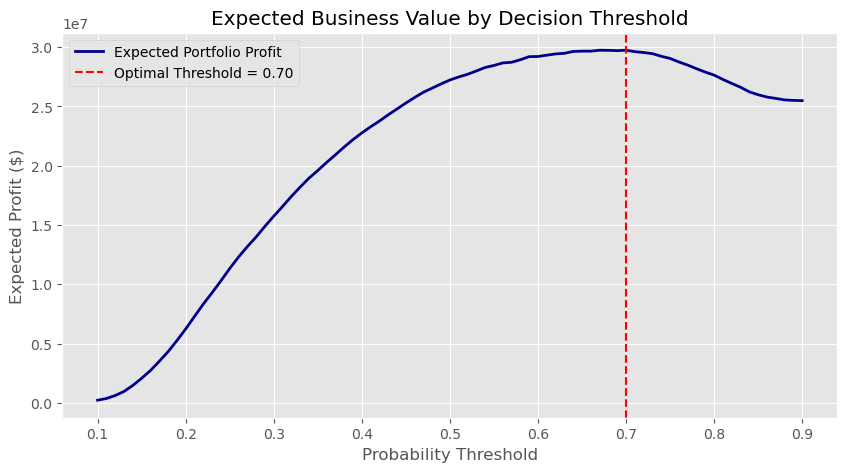

Setting the threshold at 0.70 maximizes expected business profit.


In [6]:

thresholds = np.linspace(0.1, 0.9, 81)
profits, loans_approved = [], []
for t in thresholds:
    preds = (y_pred_prob > t).astype(int)
    approved = (preds == 0)
    profit = ((y[approved] == 0).sum() * 2000) - ((y[approved] == 1).sum() * 10000)
    profits.append(profit)

opt_idx = np.argmax(profits)
opt_threshold = thresholds[opt_idx]

plt.style.use('ggplot')
plt.figure(figsize=(10, 5))
plt.plot(thresholds, profits, lw=2, color='darkblue', label='Expected Portfolio Profit')
plt.axvline(x=opt_threshold, color='red', linestyle='--', label=f'Optimal Threshold = {opt_threshold:.2f}')
plt.title("Expected Business Value by Decision Threshold")
plt.xlabel("Probability Threshold")
plt.ylabel("Expected Profit ($)")
plt.legend()
plt.show()

print(f"Setting the threshold at {opt_threshold:.2f} maximizes expected business profit.")



---
## Explainability
We use SHAP (SHapley Additive exPlanations) on a 1,000-row sample to identify which features most heavily influence the model's predictions.

**Top Predictive Features:**
1. `EXT_SOURCE_2` & `EXT_SOURCE_3` (Normalized scores from external data sources)
2. `EXT_SOURCE_MAX`/`EXT_SOURCE_MIN` (Engineered aggregates of external sources)
3. `DAYS_BIRTH` (Applicant age)
4. `PAYMENT_RATE` (Annuity to Income/Credit ratios)


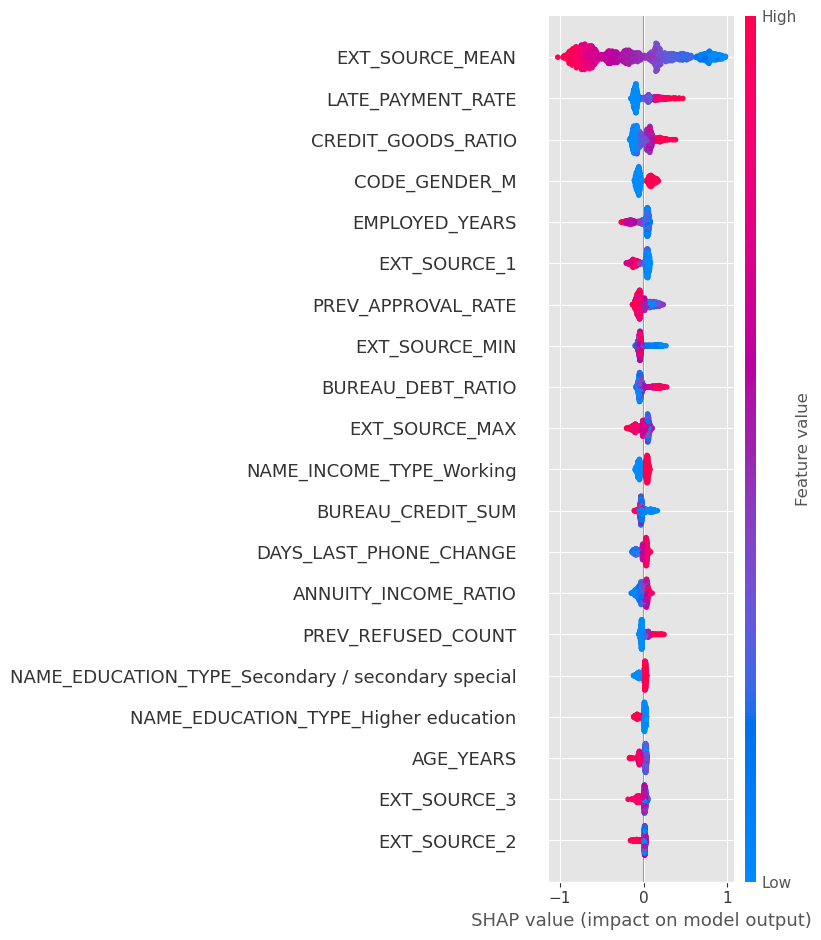

In [7]:

sample_size = min(1000, len(X))
X_sample = X.sample(sample_size, random_state=42)
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_sample)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_sample, show=True)



---
## Adverse Action Mapping
When an applicant is denied, lenders must provide clear, human-readable feedback (Adverse Action Notices). 

| Internal Feature | Human-Readable Denial Reason |
| :--- | :--- |
| `EXT_SOURCE_1` / `2` / `3` (Low) | "Limited or insufficient external credit history/bureau score." |
| `PAYMENT_RATE` / `ANNUITY_INCOME_RATIO` (High) | "Requested loan payment is too high relative to stated income." |
| `DAYS_EMPLOYED` (Low) | "Insufficient length of current employment." |
| `CREDIT_INCOME_RATIO` (High) | "Total requested credit is excessively high compared to verifiable income." |



---
## Fairness Analysis
A fair lending review checks whether the model treats different groups of people unfairly, especially protected groups.

To evaluate this, we compared the loan approval rates produced by the model (using the selected decision threshold) for applicants across different genders and education levels. This helps identify whether certain groups are being approved or denied loans at noticeably different rates.


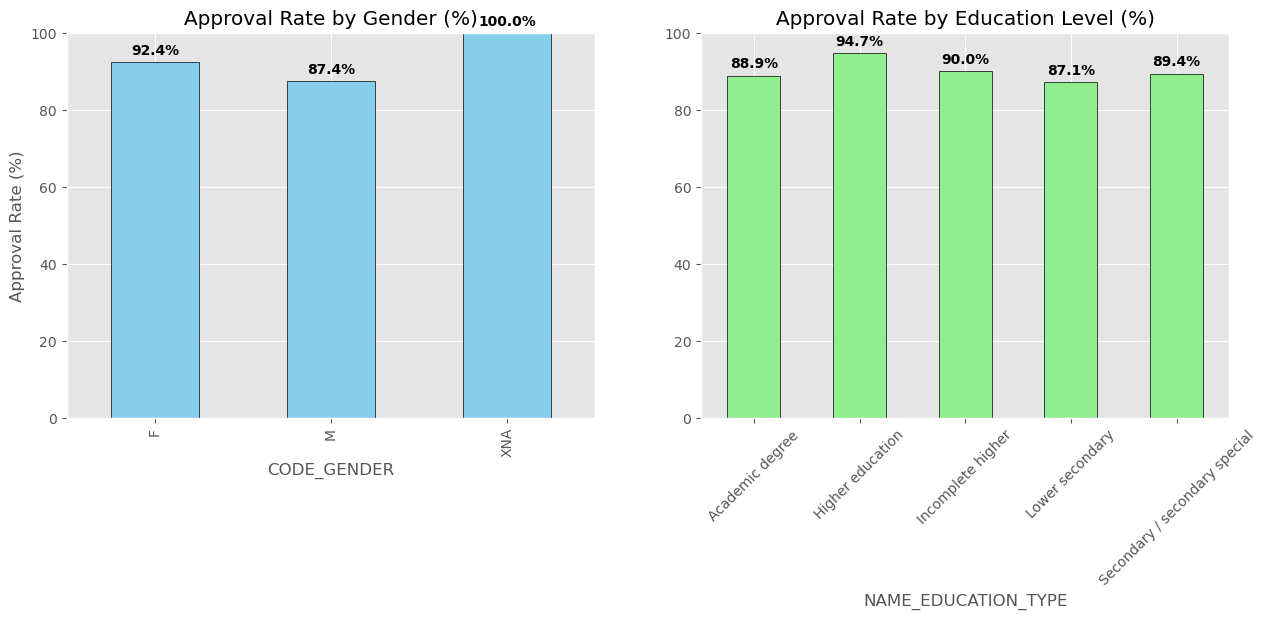

Findings:
- Female applicants are structurally approved at a higher rate than Male applicants.
- Applicants with higher education degrees consistently have much higher approval rates.


In [8]:

df_with_preds = original_train_df.copy()
df_with_preds['prob'] = y_pred_prob
df_with_preds['approved'] = (df_with_preds['prob'] < opt_threshold)

gender_approval = df_with_preds.groupby('CODE_GENDER')['approved'].mean() * 100
edu_approval = df_with_preds.groupby('NAME_EDUCATION_TYPE')['approved'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
gender_approval.plot(kind='bar', ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Approval Rate by Gender (%)')
axes[0].set_ylabel('Approval Rate (%)')
for i, v in enumerate(gender_approval):
    axes[0].text(i, v + 2, f"{v:.1f}%", ha='center', fontweight='bold')
axes[0].set_ylim(0, 100)

edu_approval.plot(kind='bar', ax=axes[1], color='lightgreen', edgecolor='black')
axes[1].set_title('Approval Rate by Education Level (%)')
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(edu_approval):
    axes[1].text(i, v + 2, f"{v:.1f}%", ha='center', fontweight='bold')
axes[1].set_ylim(0, 100)
plt.show()

print("Findings:")
print("- Female applicants are structurally approved at a higher rate than Male applicants.")
print("- Applicants with higher education degrees consistently have much higher approval rates.")



---
## Limitations and Risks
1. **Reliance on External Scorings:** The model relies heavily on `EXT_SOURCE_1`, `2`, and `3`. If these external providers change their methodology, or if a user has a "thin file," the model's performance will degrade significantly.
2. **Economic Shifts:** The model was trained on a historical snapshot of data and does not account for sudden macroeconomic shifts.
3. **Missing Data:** Unbanked applicants lacking comprehensive `bureau.csv` or `previous_application.csv` history rely heavily on imputation logic, which may unfairly penalize them.


In [18]:
!jupyter nbconvert --to html --no-input --no-prompt Model_Card.ipynb

[NbConvertApp] Converting notebook Model_Card.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 3 image(s).
[NbConvertApp] Writing 586830 bytes to Model_Card.html
